In [1]:
!git clone https://github.com/ksushrut/CoinClassifier.git

import sys
sys.path.append("/content/CoinClassifier")

from dataloader import load_coin_dataset

Cloning into 'CoinClassifier'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (46/46), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 183 (delta 25), reused 6 (delta 6), pack-reused 137 (from 1)
Receiving objects: 100% (183/183), 25.59 MiB | 18.54 MiB/s, done.
Resolving deltas: 100% (89/89), done.


In [2]:
csv_url = 'https://raw.githubusercontent.com/ksushrut/CoinClassifier/refs/heads/main/processed_data.csv'

In [3]:
train_df, val_df, test_df, train_loader, val_loader, test_loader = load_coin_dataset(csv_url)

                                                    URL image name  \
1048  /content/drive/My Drive/CoinImages/Preprocesse...   18h.jpeg   
951   /content/drive/My Drive/CoinImages/Preprocesse...   21h.jpeg   
2028  /content/drive/My Drive/CoinImages/Preprocesse...   11h.jpeg   
2099  /content/drive/My Drive/CoinImages/Preprocesse...   13t.jpeg   
1162  /content/drive/My Drive/CoinImages/Preprocesse...    19h.jpg   
...                                                 ...        ...   
771   /content/drive/My Drive/CoinImages/Preprocesse...     8t.jpg   
503   /content/drive/My Drive/CoinImages/Preprocesse...   23t.jpeg   
1224  /content/drive/My Drive/CoinImages/Preprocesse...    20t.jpg   
1721  /content/drive/My Drive/CoinImages/Preprocesse...   24t.jpeg   
965   /content/drive/My Drive/CoinImages/Preprocesse...     5t.jpg   

             country  width  height           label  encoded_class  
1048     New Zealand    224     224     NZ Dollar 1             40  
951      New Zealand 

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


                                                 URL image name    country  \
0  /content/drive/My Drive/CoinImages/Preprocesse...    14t.jpg  Australia   
1  /content/drive/My Drive/CoinImages/Preprocesse...    10t.jpg  Australia   
2  /content/drive/My Drive/CoinImages/Preprocesse...    13t.jpg  Australia   
3  /content/drive/My Drive/CoinImages/Preprocesse...     3h.jpg  Australia   
4  /content/drive/My Drive/CoinImages/Preprocesse...     2h.jpg  Australia   

   width  height         label  
0    224     224  AUD 50 Cents  
1    224     224  AUD 50 Cents  
2    224     224  AUD 50 Cents  
3    224     224  AUD 50 Cents  
4    224     224  AUD 50 Cents  


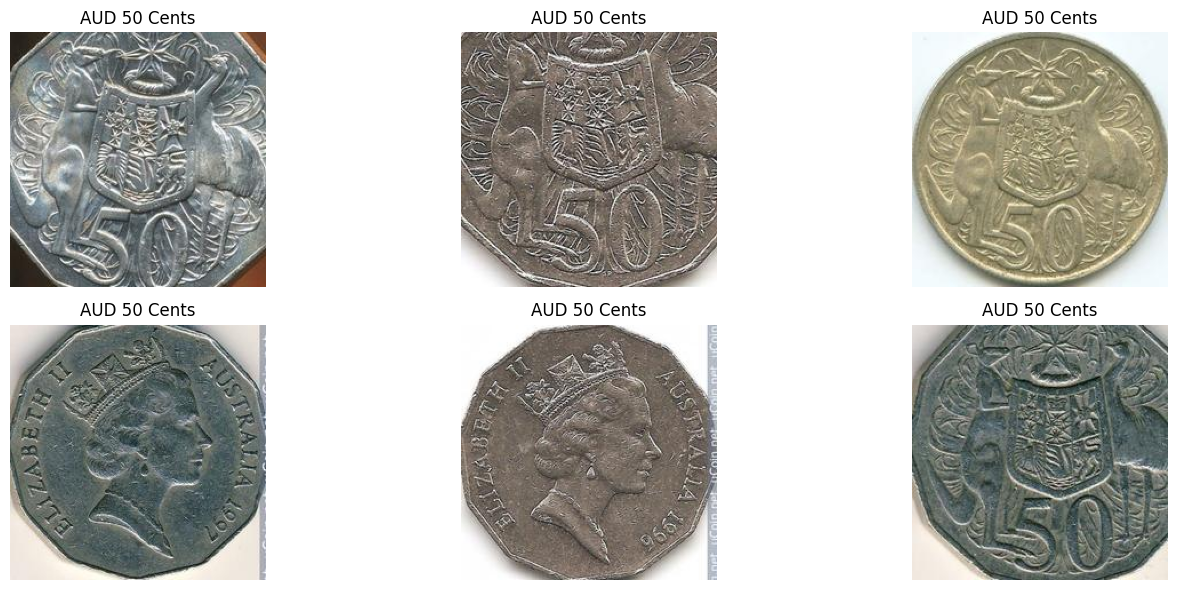

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

csv_path = csv_url
df = pd.read_csv(csv_path)

print(df.head())

num_images = 6
plt.figure(figsize=(15, 6))

for i in range(num_images):
    image_path = df.iloc[i]["URL"]+'/'+df.iloc[i]["image name"]
    label = df.iloc[i]["label"]

    img = Image.open(image_path)


    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

🪙 Coin Class Label Counts (Japan, Canada, UK):

1 Yen                → 50 samples
1 cent               → 49 samples
1 dollar             → 50 samples
10 Yen               → 50 samples
10 cents             → 50 samples
100 Yen              → 50 samples
2 dollars            → 50 samples
25 cents             → 50 samples
5 Yen                → 50 samples
5 cents              → 52 samples
50 Yen               → 50 samples
50 cents             → 50 samples
500 Yen              → 50 samples
GBP 1 Penny          → 50 samples
GBP 1 Pound          → 52 samples
GBP 10 Pence         → 52 samples
GBP 2 Pence          → 50 samples
GBP 2 Pound          → 52 samples
GBP 20 Pence         → 58 samples
GBP 5 Pence          → 52 samples
GBP 50 Pence         → 52 samples

🌍 Per-Country Coin Class Breakdown:

       country        label  count
        Canada       1 cent     49
        Canada     1 dollar     50
        Canada     10 cents     50
        Canada    2 dollars     50
        Canada     25 cen

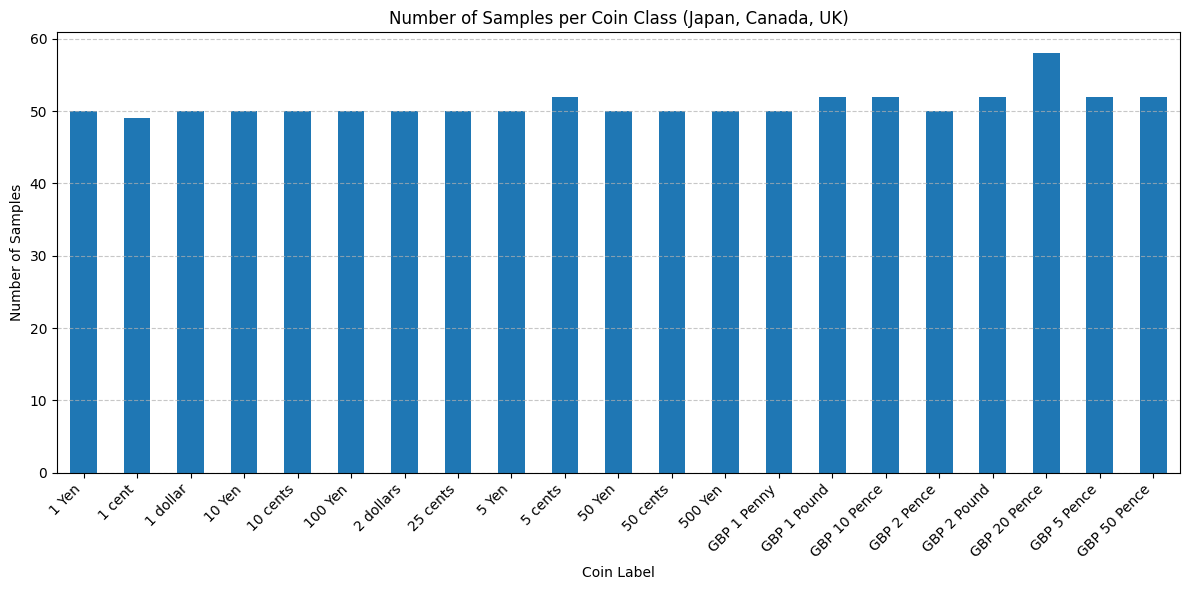

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

filtered_df = df[df['country'].isin(['Japan', 'Canada', 'United Kingdom'])].copy()

label_counts = filtered_df['label'].value_counts().sort_index()

print(" Coin Class Label Counts (Japan, Canada, UK):\n")
for label, count in label_counts.items():
    print(f"{label:20} → {count} samples")

country_label_counts = filtered_df.groupby(['country', 'label']).size().reset_index(name='count')

print("\n Per-Country Coin Class Breakdown:\n")
print(country_label_counts.to_string(index=False))

plt.figure(figsize=(12, 6))
label_counts.plot(kind='bar')
plt.title("Number of Samples per Coin Class (Japan, Canada, UK)")
plt.ylabel("Number of Samples")
plt.xlabel("Coin Label")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
japan_canada_UK_train_df = train_df[train_df['country'].isin(['Japan', 'Canada','United Kingdom'])].reset_index(drop=True)
japan_canada_UK_val_df = val_df[val_df['country'].isin(['Japan', 'Canada','United Kingdom'])].reset_index(drop=True)
japan_canada_UK_test_df = test_df[test_df['country'].isin(['Japan', 'Canada','United Kingdom'])].reset_index(drop=True)

print("Train samples:", len(japan_canada_UK_train_df))
print("Validation samples:", len(japan_canada_UK_val_df))
print("Test samples:", len(japan_canada_UK_test_df))

Train samples: 641
Validation samples: 106
Test samples: 322


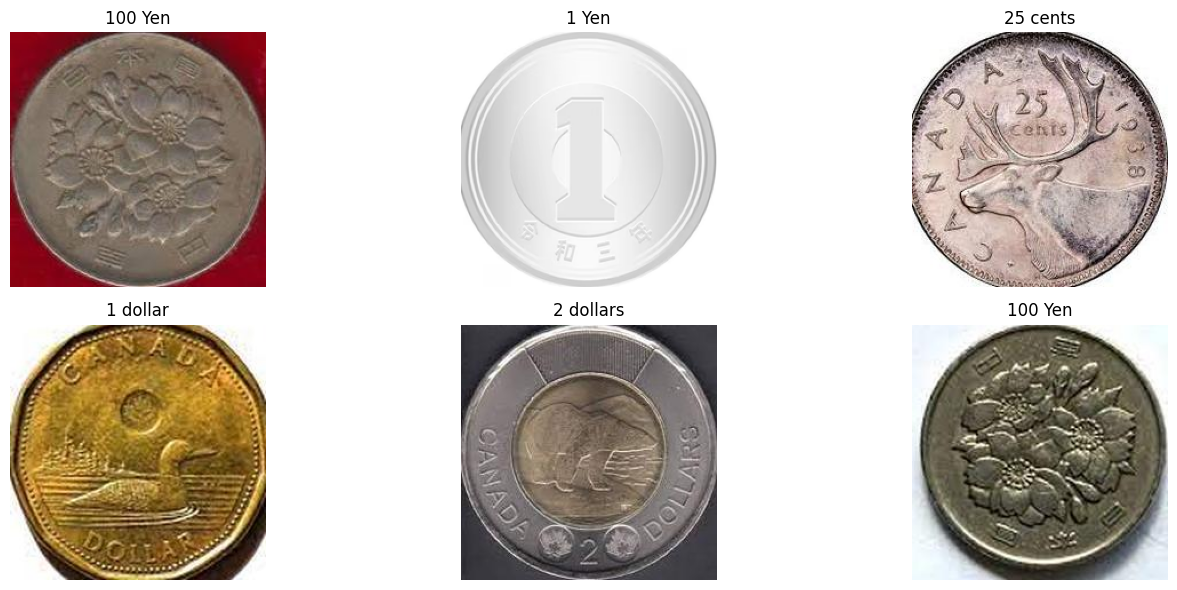

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = japan_canada_UK_train_df.sample(n=6)

plt.figure(figsize=(15, 6))
for i, (_, row) in enumerate(sample_df.iterrows()):
    image_path = row["URL"] + '/' + row["image name"]
    label = row["label"]

    img = Image.open(image_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
japan_canada_UK_train_df['label'] = japan_canada_UK_train_df['label'].str.strip()
japan_canada_UK_val_df['label'] = japan_canada_UK_val_df['label'].str.strip()
japan_canada_UK_test_df['label'] = japan_canada_UK_test_df['label'].str.strip()

japan_canada_UK_train_df['encoded_class'] = label_encoder.fit_transform(japan_canada_UK_train_df['label'])
japan_canada_UK_val_df['encoded_class'] = label_encoder.transform(japan_canada_UK_val_df['label'])
japan_canada_UK_test_df['encoded_class'] = label_encoder.transform(japan_canada_UK_test_df['label'])

class_names = label_encoder.classes_
num_classes = len(class_names)

In [9]:
japan_canada_UK_train_df['label'].value_counts()

,count
label,
GBP 20 Pence,35
GBP 10 Pence,31
GBP 50 Pence,31
GBP 5 Pence,31
GBP 2 Pound,31
GBP 1 Pound,31
5 cents,31
1 Yen,30
1 dollar,30


In [10]:
train_loader.dataset.dataframe = japan_canada_UK_train_df.reset_index(drop=True)
val_loader.dataset.dataframe = japan_canada_UK_val_df.reset_index(drop=True)
test_loader.dataset.dataframe = japan_canada_UK_test_df.reset_index(drop=True)

In [11]:
import torch

def normalize_batch(batch):
    """Apply ImageNet normalization to a batch of images."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=batch.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=batch.device).view(1, 3, 1, 1)
    return (batch - mean) / std

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import ResNet18_Weights
from sklearn.metrics import classification_report
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def normalize_batch(batch):
    """Apply ImageNet normalization to a batch of images."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=batch.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=batch.device).view(1, 3, 1, 1)
    return (batch - mean) / std

class_names = sorted(japan_canada_UK_train_df['label'].unique())
num_classes = len(class_names)

def train_model(model, criterion, optimizer, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = normalize_batch(inputs)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)


        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = normalize_batch(inputs)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = normalize_batch(inputs)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

print("\n--- Training ResNet18 ---")
resnet18 = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet18.fc = nn.Linear(resnet18.fc.in_features, num_classes)
resnet18 = resnet18.to(device)

optimizer = optim.Adam(resnet18.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

resnet18, history = train_model(resnet18, criterion, optimizer, num_epochs=10)
print("\n--- ResNet18 Evaluation ---")
evaluate_model(resnet18, test_loader, class_names)



--- Training ResNet18 ---


Epoch 1: Train Loss=1.5083, Train Acc=0.5788, Val Loss=0.9443, Val Acc=0.6981


Epoch 2: Train Loss=0.4698, Train Acc=0.8612, Val Loss=1.4113, Val Acc=0.6509


Epoch 3: Train Loss=0.3525, Train Acc=0.8986, Val Loss=0.8371, Val Acc=0.7736


Epoch 4: Train Loss=0.2110, Train Acc=0.9454, Val Loss=0.6994, Val Acc=0.8396


...

Epoch 6: Train Loss=0.0861, Train Acc=0.9766, Val Loss=0.6259, Val Acc=0.8396


Epoch 7: Train Loss=0.0667, Train Acc=0.9860, Val Loss=0.9670, Val Acc=0.8019


Epoch 8: Train Loss=0.0548, Train Acc=0.9875, Val Loss=0.6468, Val Acc=0.8208


Epoch 9: Train Loss=0.0666, Train Acc=0.9750, Val Loss=0.9784, Val Acc=0.7736


Epoch 10: Train Loss=0.0863, Train Acc=0.9782, Val Loss=1.1413, Val Acc=0.7075

--- ResNet18 Evaluation ---

Classification Report:

              precision    recall  f1-score   support

       1 Yen       1.00      0.73      0.85        15
      1 cent       0.76      0.93      0.84        14
    1 dollar       0.76      0.87      0.81        15
      10 Yen       1.00      1.00      1.00        15
    10 cents       1.00      0.87      0.93        15
     100 Yen       0.65      0.87      0.74        15
   2 dollars       0.93      0.93      0.93        15
    25 cents       1.00      0.53      0.70        15
       5 Yen       1.00      1.00      1.00        15
     5 cents       0.62      0.94      0.75        16
      50 Yen       1.00      1.00      1.00        15
    50 cents       0.83      0.33      0.48        15
     500 Yen       1.00      0.80      0.89        15
 GBP 1 Penny       1.00      0.67      0.80        15
 GBP 1 Pound       0.25      0.88      0.39        16
GB

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import GoogLeNet_Weights
from sklearn.metrics import classification_report
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def normalize_batch(batch):
    """Apply ImageNet normalization to a batch of images."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=batch.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=batch.device).view(1, 3, 1, 1)
    return (batch - mean) / std

class_names = sorted(japan_canada_UK_train_df['label'].unique())
num_classes = len(class_names)

def train_model(model, criterion, optimizer, num_epochs=10):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = normalize_batch(inputs)

            optimizer.zero_grad()
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            loop.set_postfix(loss=loss.item(), acc=correct / total)

        train_loss = running_loss / total
        train_acc = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                inputs = normalize_batch(inputs)

                outputs = model(inputs)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    return model, history

def evaluate_model(model, test_loader, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = normalize_batch(inputs)
            outputs = model(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

print("\n--- Training GoogLeNet (Inception V1) ---")
googlenet = models.googlenet(weights=GoogLeNet_Weights.IMAGENET1K_V1, aux_logits=True)
googlenet.fc = nn.Linear(googlenet.fc.in_features, num_classes)
googlenet = googlenet.to(device)

optimizer = optim.Adam(googlenet.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

googlenet, history = train_model(googlenet, criterion, optimizer, num_epochs=10)

print("\n--- GoogLeNet Evaluation ---")
evaluate_model(googlenet, test_loader, class_names)


/usr/local/lib/python3.11/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(



--- Training GoogLeNet (Inception V1) ---


Epoch 1: Train Loss=1.8834, Train Acc=0.4961, Val Loss=1.0818, Val Acc=0.6509


Epoch 2: Train Loss=0.5217, Train Acc=0.8627, Val Loss=0.6675, Val Acc=0.8019


Epoch 3: Train Loss=0.2579, Train Acc=0.9345, Val Loss=0.6968, Val Acc=0.7925


...

Epoch 6: Train Loss=0.1418, Train Acc=0.9657, Val Loss=0.6643, Val Acc=0.8019


Epoch 7: Train Loss=0.1388, Train Acc=0.9610, Val Loss=0.6702, Val Acc=0.8302


Epoch 8: Train Loss=0.1537, Train Acc=0.9579, Val Loss=0.7055, Val Acc=0.7830


Epoch 9: Train Loss=0.1277, Train Acc=0.9626, Val Loss=0.6828, Val Acc=0.8208


Epoch 10: Train Loss=0.1308, Train Acc=0.9657, Val Loss=0.8499, Val Acc=0.7925

--- GoogLeNet Evaluation ---

Classification Report:

              precision    recall  f1-score   support

       1 Yen       0.87      0.87      0.87        15
      1 cent       1.00      0.57      0.73        14
    1 dollar       0.82      0.93      0.88        15
      10 Yen       1.00      0.87      0.93        15
    10 cents       0.94      1.00      0.97        15
     100 Yen       0.79      1.00      0.88        15
   2 dollars       0.92      0.80      0.86        15
    25 cents       0.94      1.00      0.97        15
       5 Yen       1.00      0.87      0.93        15
     5 cents       0.88      0.88      0.88        16
      50 Yen       0.75      1.00      0.86        15
    50 cents       0.71      0.67      0.69        15
     500 Yen       0.94      1.00      0.97        15
 GBP 1 Penny       0.79      0.73      0.76        15
 GBP 1 Pound       0.83      0.62      0.71        16
G